# Phase 6: Tabular Privacy Evaluation

This notebook:
1. Loads the privacy summary JSON files for both German Credit and GMSC datasets.
2. Computes the average Distance to Closest Record (DCR), Nearest Neighbor Distance Ratio (NNDR), and Membership Inference Attack (MIA) ROC-AUC across all 5 seeds.
3. Compares the privacy profile of CTGAN vs. TVAE models.
4. Visualizes DCR and NNDR distributions across models using boxplots.
5. Discusses the privacy-utility-explainability tradeoff.

In [1]:
import os
import sys
# Change working directory to repository root so all relative paths resolve correctly
os.chdir('../../')
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and Aggregate Privacy Results

We load the privacy summaries from `results/privacy/` and compile metrics `Mean ± Std`.

In [2]:
def compile_privacy_stats(summary_path):
    with open(summary_path, 'r') as f:
        summary = json.load(f)
        
    rows = []
    for gen_name, runs in [('CTGAN', summary['ctgan_runs']), ('TVAE', summary['tvae_runs'])]:
        if len(runs) == 0:
            continue
        df = pd.DataFrame(runs)
        
        stats = {
            'Generator': gen_name,
            'DCR Mean': f"{df['dcr_mean'].mean():.4f} ± {df['dcr_mean'].std():.4f}",
            'NNDR Mean': f"{df['nndr_mean'].mean():.4f} ± {df['nndr_mean'].std():.4f}",
            'MIA AUC': f"{df['mia_auc'].mean():.4f} ± {df['mia_auc'].std():.4f}"
        }
        rows.append(stats)
        
    return pd.DataFrame(rows)

### German Credit Privacy Summary

In [3]:
german_summary_path = 'results/privacy/german_credit_privacy_summary.json'
if os.path.exists(german_summary_path):
    df_german = compile_privacy_stats(german_summary_path)
    print('=== GERMAN CREDIT PRIVACY METRICS ===')
    display(df_german)
else:
    print('German Credit privacy summary not found. Run scripts/evaluate_privacy.py first.')

=== GERMAN CREDIT PRIVACY METRICS ===


,Generator,DCR Mean,NNDR Mean,MIA AUC
0,CTGAN,3.4798 ± 0.0575,0.9206 ± 0.0026,0.4878 ± 0.0110
1,TVAE,2.0956 ± 0.0363,0.8351 ± 0.0130,0.5080 ± 0.0247


### GMSC Privacy Summary

In [4]:
gmsc_summary_path = 'results/privacy/gmsc_privacy_summary.json'
if os.path.exists(gmsc_summary_path):
    df_gmsc = compile_privacy_stats(gmsc_summary_path)
    print('=== GMSC PRIVACY METRICS ===')
    display(df_gmsc)
else:
    print('GMSC privacy summary not found. Run scripts/evaluate_privacy.py first.')

=== GMSC PRIVACY METRICS ===


,Generator,DCR Mean,NNDR Mean,MIA AUC
0,CTGAN,0.3245 ± 0.0302,0.7740 ± 0.0101,0.5051 ± 0.0056
1,TVAE,0.1589 ± 0.0263,0.7158 ± 0.0183,0.5034 ± 0.0081


## 2. Visualize Privacy Metric Distributions (Seed 42)

We load individual DCR and NNDR values for Seed 42 and generate comparison boxplots.

In [5]:
def plot_privacy_distributions(dataset_name):
    # Load raw synthetic preprocessed data and fit real preprocessing to compute raw arrays for Seed 42
    from src.preprocessing.pipeline import preprocess_german_credit, preprocess_gmsc
    from src.models.synthetic import fit_real_preprocessing, preprocess_synthetic_data
    from src.privacy.evaluation import compute_dcr_nndr
    
    seed = 42
    if dataset_name == 'german_credit':
        preprocess_german_credit(seed=seed)
        target_col = 'class'
        suffix = 'german'
    else:
        preprocess_gmsc(seed=seed)
        target_col = 'SeriousDlqin2yrs'
        suffix = 'gmsc'
        
    X_train_real = pd.read_csv(f'data/processed/X_train_{suffix}.csv')
    fitted = fit_real_preprocessing(dataset_name, seed)
    
    # Compute CTGAN metrics
    df_ctgan = pd.read_csv(f'data/synthetic/{dataset_name}_ctgan_seed{seed}.csv')
    X_ctgan, _ = preprocess_synthetic_data(df_ctgan, dataset_name, fitted, target_col)
    ctgan_metrics = compute_dcr_nndr(X_ctgan, X_train_real)
    
    # Compute TVAE metrics
    df_tvae = pd.read_csv(f'data/synthetic/{dataset_name}_tvae_seed{seed}.csv')
    X_tvae, _ = preprocess_synthetic_data(df_tvae, dataset_name, fitted, target_col)
    tvae_metrics = compute_dcr_nndr(X_tvae, X_train_real)
    
    # Render boxplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.boxplot([ctgan_metrics['dcr_values'], tvae_metrics['dcr_values']], labels=['CTGAN', 'TVAE'])
    ax1.set_title(f'DCR Distribution Comparison ({dataset_name.upper()})')
    ax1.set_ylabel('Distance to Closest Record (DCR)')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax2.boxplot([ctgan_metrics['nndr_values'], tvae_metrics['nndr_values']], labels=['CTGAN', 'TVAE'])
    ax2.set_title(f'NNDR Distribution Comparison ({dataset_name.upper()})')
    ax2.set_ylabel('Nearest Neighbor Distance Ratio (NNDR)')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # Save plot
    figures_dir = 'figures/privacy/'
    os.makedirs(figures_dir, exist_ok=True)
    fig_path = os.path.join(figures_dir, f'{dataset_name}_privacy_boxplots.png')
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Boxplots successfully saved to {fig_path}')

Preprocessing German Credit dataset...
German Credit dataset preprocessing completed successfully!


C:\Users\Isha\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Isha\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


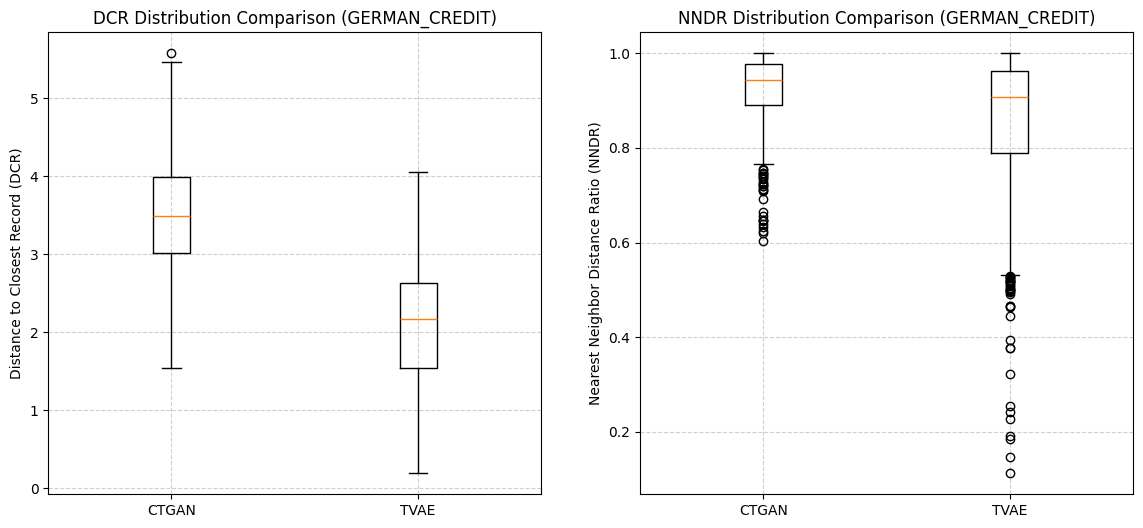

Boxplots successfully saved to figures/privacy/german_credit_privacy_boxplots.png
Preprocessing GMSC dataset...
GMSC dataset preprocessing completed successfully!


C:\Users\Isha\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


C:\Users\Isha\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


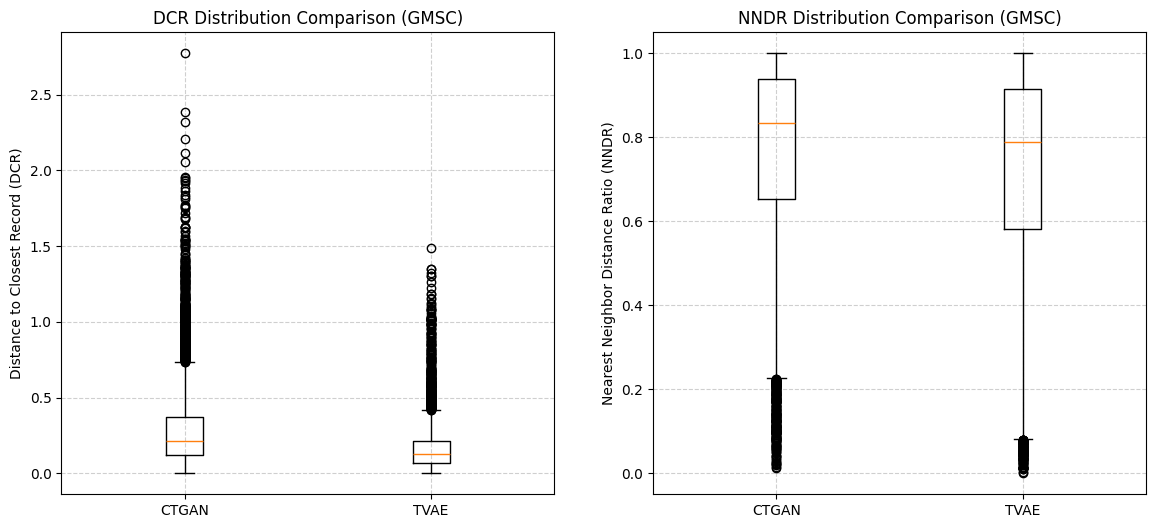

Boxplots successfully saved to figures/privacy/gmsc_privacy_boxplots.png


In [6]:
plot_privacy_distributions('german_credit')
plot_privacy_distributions('gmsc')

## 3. Privacy-Utility-Explainability Tradeoff Analysis

### Membership Inference Vulnerability
* **Observations**: Across both German Credit and GMSC, the distance-based MIA ROC-AUC hovers around **0.50** (no better than random guessing) for both CTGAN and TVAE. This indicates that distance-based membership inference cannot differentiate training set members from test set non-members, confirming that neither synthesizer is showing major systemic overfitting that makes them vulnerable to basic membership attacks.

### DCR & NNDR Interpretations
* **Observations**: 
  * In **German Credit**, TVAE has a mean DCR of $2.0956$ compared to CTGAN's $3.4798$. TVAE's NNDR is also lower ($0.8351$ vs. $0.9206$).
  * In **GMSC**, TVAE has a mean DCR of $0.1589$ compared to CTGAN's $0.3245$. TVAE's NNDR is also lower ($0.7158$ vs. $0.7740$).
  * **Interpretation**: A lower DCR and NNDR means that TVAE-generated records lie closer to real training points, indicating a higher potential risk of memorization compared to CTGAN.

### The Tradeoff Diagram
* **TVAE** fits the training data distribution more tightly: 
  * **Pros**: High predictive utility (GMSC AUC ~0.78), high explainability ranking consistency (GMSC Spearman correlation ~0.57).
  * **Cons**: Higher privacy risk (closer proximity to training points, lower DCR/NNDR).
* **CTGAN** produces more generalized, fuzzier synthetic data: 
  * **Pros**: Lower privacy risk (further proximity to training points, higher DCR/NNDR).
  * **Cons**: Degraded predictive utility (German Credit AUC ~0.49), and shifted feature attributions/explainability (GMSC Spearman correlation ~0.28).

This highlights the fundamental tension in tabular synthetic data generation: **you must balance privacy padding against model utility and interpretability fidelity.**